# Dual-Timescale QRC Prototype

**Team QuantumEdge - GIC 2026 Phase 2**  
**Notebook owner: Van Tien Nguyen**

This notebook produces the preliminary simulator numbers requested in the Phase 2 draft:

1. Generate two public, reproducible chaotic benchmarks: Mackey-Glass and Lorenz.
2. Build two fixed transverse-field Ising quantum reservoirs in PennyLane.
3. Compare two readouts:
   - Pauli-only: single-qubit $\langle Z_i \rangle$ and nearest-neighbor $\langle Z_i Z_{i+1} \rangle$ features.
   - Pauli + entanglement spectrum: Pauli features plus half-chain entanglement energies.
4. Train only a classical ridge-regression readout.
5. Report RMSE improvement from entanglement-spectrum features and the single-reservoir ablation RMSE for the paper table.

The notebook is intentionally standalone: it installs missing Python packages, generates all data in place, and does not import any local project code.


## 0. Package Bootstrap

Run this first in a fresh qBraid/Jupyter kernel. The cell installs only packages that are missing, so re-running the notebook does not reinstall everything.


In [1]:
import importlib.util
import subprocess
import sys

REQUIRED_PACKAGES = {
    "numpy": "numpy",
    "scipy": "scipy",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
    "pandas": "pandas",
    "pennylane": "pennylane",
}

missing = [package for module, package in REQUIRED_PACKAGES.items()
           if importlib.util.find_spec(module) is None]

if missing:
    print("Installing missing packages:", ", ".join(missing))
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *missing])
else:
    print("All required packages are already installed.")


All required packages are already installed.


## 1. Imports, Configuration, and Reproducibility

The quantum reservoirs are fixed feature maps. The only trained component is the ridge-regression readout, so the random seed mainly controls any library-level stochastic behavior and keeps the notebook reproducible.


In [2]:
from dataclasses import dataclass
from pathlib import Path
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pennylane as qml
from scipy.integrate import solve_ivp
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler

warnings.filterwarnings("ignore", category=UserWarning)

SEED = 42
rng = np.random.default_rng(SEED)
np.random.seed(SEED)

@dataclass(frozen=True)
class ReservoirConfig:
    """Fixed Ising-reservoir parameters used by one branch of the dual QRC."""
    name: str
    n_qubits: int
    coupling_j: float
    transverse_h: float
    trotter_depth: int

N_QUBITS = 9
SHORT_RESERVOIR = ReservoirConfig(
    name="short-memory",
    n_qubits=N_QUBITS,
    coupling_j=0.3,
    transverse_h=1.0,
    trotter_depth=2,
)
LONG_RESERVOIR = ReservoirConfig(
    name="long-memory",
    n_qubits=N_QUBITS,
    coupling_j=1.2,
    transverse_h=0.4,
    trotter_depth=6,
)

N_TRAIN = 1_000
N_TEST = 500
N_TOTAL = N_TRAIN + N_TEST + 1  # one extra point is needed for one-step-ahead targets
N_ENT_FEATURES = min(2 ** (N_QUBITS // 2), 8)
RIDGE_ALPHAS = np.logspace(-6, 6, 25)
FIGURE_PATH = Path("qrc_forecast_comparison.png")

plt.rcParams.update({
    "figure.figsize": (12, 4),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 10,
})

print("PennyLane version:", qml.__version__)
print("NumPy version:", np.__version__)
print("Reservoirs:")
for cfg in (SHORT_RESERVOIR, LONG_RESERVOIR):
    print(
        f"  {cfg.name:<13} n={cfg.n_qubits}, J={cfg.coupling_j}, "
        f"h={cfg.transverse_h}, p={cfg.trotter_depth}"
    )
print(f"Train targets: {N_TRAIN}; test targets: {N_TEST}; entanglement features/reservoir: {N_ENT_FEATURES}")


PennyLane version: 0.43.0
NumPy version: 1.26.4
Reservoirs:
  short-memory  n=9, J=0.3, h=1.0, p=2
  long-memory   n=9, J=1.2, h=0.4, p=6
Train targets: 1000; test targets: 500; entanglement features/reservoir: 8


## 2. Generate Benchmark Time Series

These synthetic benchmarks are used only to validate the proposed readout design before the Phase 3 financial-volatility benchmark. Mackey-Glass stresses delayed nonlinear memory; Lorenz stresses chaotic continuous-time dynamics.


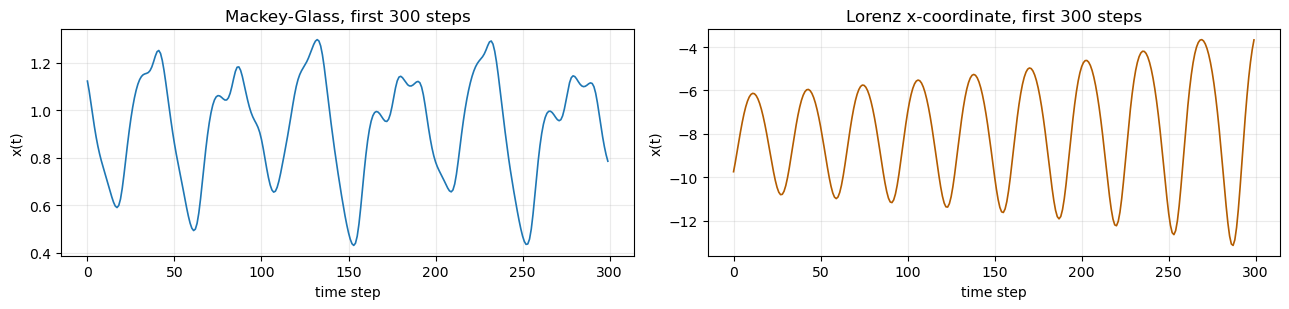

Mackey-Glass length: 1501
Lorenz length:       1501


In [3]:
def mackey_glass(n_steps, tau=17, beta=0.2, gamma=0.1, exponent=10, dt=1.0, x0=1.2):
    """Generate a Mackey-Glass delay-differential time series with Euler stepping."""
    delay = int(tau / dt)
    history = delay + 1
    x = np.empty(n_steps + history, dtype=float)
    x[:history] = x0

    for t in range(history, n_steps + history):
        x_tau = x[t - delay]
        dx = beta * x_tau / (1.0 + x_tau ** exponent) - gamma * x[t - 1]
        x[t] = x[t - 1] + dt * dx

    return x[history:]


def lorenz_x_series(n_steps, sigma=10.0, rho=28.0, beta=8.0 / 3.0, dt=0.02):
    """Integrate the Lorenz system and return the x-coordinate."""
    def rhs(_t, state):
        x, y, z = state
        return [
            sigma * (y - x),
            x * (rho - z) - y,
            x * y - beta * z,
        ]

    t_eval = np.arange(n_steps) * dt
    solution = solve_ivp(
        rhs,
        t_span=(t_eval[0], t_eval[-1]),
        y0=[1.0, 1.0, 1.0],
        t_eval=t_eval,
        method="RK45",
        rtol=1e-8,
        atol=1e-10,
    )
    if not solution.success:
        raise RuntimeError(f"Lorenz integration failed: {solution.message}")
    return solution.y[0]


def discard_transient(series, transient_steps):
    """Drop the initial transient and keep exactly N_TOTAL usable observations."""
    usable = np.asarray(series[transient_steps:transient_steps + N_TOTAL], dtype=float)
    if len(usable) != N_TOTAL:
        raise ValueError(f"Expected {N_TOTAL} observations after transient, got {len(usable)}")
    return usable

mg_raw = discard_transient(mackey_glass(N_TOTAL + 150), transient_steps=150)
lorenz_raw = discard_transient(lorenz_x_series(N_TOTAL + 300), transient_steps=300)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.2))
axes[0].plot(mg_raw[:300], color="#1f77b4", lw=1.2)
axes[0].set_title("Mackey-Glass, first 300 steps")
axes[0].set_xlabel("time step")
axes[0].set_ylabel("x(t)")

axes[1].plot(lorenz_raw[:300], color="#b35c00", lw=1.2)
axes[1].set_title("Lorenz x-coordinate, first 300 steps")
axes[1].set_xlabel("time step")
axes[1].set_ylabel("x(t)")

plt.tight_layout()
plt.show()

print(f"Mackey-Glass length: {len(mg_raw)}")
print(f"Lorenz length:       {len(lorenz_raw)}")


## 3. Normalize Inputs to Rotation Angles

The reservoirs encode each scalar input as an $RY(x_t)$ angle. To avoid test-set leakage, the min-max scaler is fit only on the training portion used by the ridge readout, then applied to the full series. Values outside the training range are clipped to the valid rotation interval.


In [4]:
def normalize_to_angles(raw_series, n_train=N_TRAIN, feature_range=(-np.pi / 2, np.pi / 2)):
    """Fit the angle scaler on the training segment and transform the whole series."""
    raw_series = np.asarray(raw_series, dtype=float)
    scaler = MinMaxScaler(feature_range=feature_range)

    # The training readout predicts y[0:n_train], which includes raw index n_train.
    scaler.fit(raw_series[:n_train + 1].reshape(-1, 1))
    angles = scaler.transform(raw_series.reshape(-1, 1)).ravel()
    angles = np.clip(angles, feature_range[0], feature_range[1])
    return angles, scaler

mg_angles, mg_scaler = normalize_to_angles(mg_raw)
lorenz_angles, lorenz_scaler = normalize_to_angles(lorenz_raw)

normalization_summary = pd.DataFrame({
    "series": ["Mackey-Glass", "Lorenz"],
    "raw_min": [mg_raw.min(), lorenz_raw.min()],
    "raw_max": [mg_raw.max(), lorenz_raw.max()],
    "angle_min": [mg_angles.min(), lorenz_angles.min()],
    "angle_max": [mg_angles.max(), lorenz_angles.max()],
})
normalization_summary


,series,raw_min,raw_max,angle_min,angle_max
0,Mackey-Glass,0.403035,1.325722,-1.570796,1.570796
1,Lorenz,-17.108699,17.455065,-1.570796,1.570796


## 4. Define the Quantum Reservoir Feature Map

For each scalar input $x_t$, the notebook builds the reservoir state with repeated $RY(x_t)$ encoding before every Trotter layer:

$$
H^{(r)} = J^{(r)} \sum_i Z_i Z_{i+1} + h^{(r)} \sum_i X_i, \qquad r \in \{short,long\}.
$$

The QNode returns a statevector. Classical helper functions then compute Pauli expectations and half-chain entanglement energies from that same statevector, avoiding duplicate quantum simulation calls.


In [5]:
def choose_pennylane_device():
    """Use lightning.qubit when available; otherwise fall back to default.qubit."""
    for device_name in ("lightning.qubit", "default.qubit"):
        try:
            _ = qml.device(device_name, wires=1)
            return device_name
        except Exception:
            continue
    raise RuntimeError("No compatible PennyLane statevector device is available.")

DEVICE_NAME = choose_pennylane_device()
print("Using PennyLane device:", DEVICE_NAME)


def make_statevector_qnode(config):
    """Create one fixed Ising-reservoir QNode for a scalar input angle."""
    dev = qml.device(DEVICE_NAME, wires=config.n_qubits)

    @qml.qnode(dev, interface="numpy")
    def reservoir_state(x_angle):
        # Repeated data injection increases encoding density without trainable quantum parameters.
        for _ in range(config.trotter_depth):
            for wire in range(config.n_qubits):
                qml.RY(x_angle, wires=wire)

            # Nearest-neighbor ZZ chain. IsingZZ(phi) implements exp(-i * phi/2 * Z Z).
            for wire in range(config.n_qubits - 1):
                qml.IsingZZ(2.0 * config.coupling_j, wires=[wire, wire + 1])

            # Transverse-field X rotations. RX(phi) implements exp(-i * phi/2 * X).
            for wire in range(config.n_qubits):
                qml.RX(2.0 * config.transverse_h, wires=wire)

        return qml.state()

    return reservoir_state


def pauli_z_features_from_state(statevector, n_qubits):
    """Return [<Z_i>, <Z_i Z_{i+1}>] from a statevector."""
    probabilities = np.abs(np.asarray(statevector, dtype=np.complex128)) ** 2
    tensor = probabilities.reshape((2,) * n_qubits)

    single_z = []
    for wire in range(n_qubits):
        marginal = tensor.sum(axis=tuple(axis for axis in range(n_qubits) if axis != wire))
        single_z.append(marginal[0] - marginal[1])

    pair_zz = []
    for wire in range(n_qubits - 1):
        keep_axes = (wire, wire + 1)
        marginal = tensor.sum(axis=tuple(axis for axis in range(n_qubits) if axis not in keep_axes))
        pair_zz.append(marginal[0, 0] + marginal[1, 1] - marginal[0, 1] - marginal[1, 0])

    return np.asarray(single_z + pair_zz, dtype=float)


def entanglement_energies_from_state(statevector, n_qubits, n_keep=N_ENT_FEATURES):
    """Return the first n_keep half-chain entanglement energies xi_k = -log(lambda_k)."""
    n_left = n_qubits // 2
    n_right = n_qubits - n_left
    psi = np.asarray(statevector, dtype=np.complex128).reshape(2 ** n_left, 2 ** n_right)

    rho_left = psi @ psi.conj().T
    eigvals = np.linalg.eigvalsh(rho_left).real
    eigvals = np.sort(np.clip(eigvals, 1e-12, 1.0))[::-1]
    energies = -np.log(eigvals)

    if len(energies) < n_keep:
        energies = np.pad(energies, (0, n_keep - len(energies)), constant_values=0.0)
    return energies[:n_keep]

short_qnode = make_statevector_qnode(SHORT_RESERVOIR)
long_qnode = make_statevector_qnode(LONG_RESERVOIR)

# Sanity check: one statevector per reservoir should generate all feature blocks.
example_angle = float(mg_angles[0])
example_state = short_qnode(example_angle)
example_pauli = pauli_z_features_from_state(example_state, N_QUBITS)
example_ent = entanglement_energies_from_state(example_state, N_QUBITS)

print(f"Statevector length: {len(example_state)}")
print(f"Pauli features per reservoir: {len(example_pauli)}")
print(f"Entanglement features per reservoir: {len(example_ent)}")
print(f"Dual Pauli-only features: {2 * len(example_pauli)}")
print(f"Dual Pauli + entanglement features: {2 * (len(example_pauli) + len(example_ent))}")


Using PennyLane device: lightning.qubit
Statevector length: 512
Pauli features per reservoir: 17
Entanglement features per reservoir: 8
Dual Pauli-only features: 34
Dual Pauli + entanglement features: 50


## 5. Extract Reservoir Features

The feature extractor returns three aligned design matrices for the same targets:

- `dual_pauli`: short-reservoir Pauli features plus long-reservoir Pauli features.
- `dual_ent`: both Pauli blocks plus both entanglement-spectrum blocks.
- `single_long_ent`: long-reservoir Pauli + entanglement features for the ablation row.


In [6]:
def extract_feature_matrices(series_angles, short_node, long_node, n_qubits, n_ent=N_ENT_FEATURES, label="series"):
    """Drive both reservoirs over a normalized time series and collect readout features."""
    series_angles = np.asarray(series_angles, dtype=float)
    dual_pauli_rows = []
    dual_ent_rows = []
    single_long_ent_rows = []

    prev_x = float(series_angles[0])
    start = time.perf_counter()
    for t, x_t in enumerate(series_angles[:-1]):
        state_short = short_node(float(x_t))
        state_long = long_node(float(x_t))

        pauli_short = pauli_z_features_from_state(state_short, n_qubits)
        pauli_long = pauli_z_features_from_state(state_long, n_qubits)
        ent_short = entanglement_energies_from_state(state_short, n_qubits, n_ent)
        ent_long = entanglement_energies_from_state(state_long, n_qubits, n_ent)
        feedback = np.array([prev_x])

        dual_pauli_rows.append(np.concatenate([pauli_short, pauli_long, feedback]))
        dual_ent_rows.append(np.concatenate([pauli_short, pauli_long, ent_short, ent_long, feedback]))
        single_long_ent_rows.append(np.concatenate([pauli_long, ent_long, feedback]))

        if (t + 1) % 250 == 0 or (t + 1) == len(series_angles) - 1:
            elapsed = time.perf_counter() - start
            print(f"{label:<13} {t + 1:4d}/{len(series_angles) - 1} feature rows in {elapsed:6.1f}s")

        prev_x = float(x_t)

    y = series_angles[1:]
    return {
        "dual_pauli": np.vstack(dual_pauli_rows),
        "dual_ent": np.vstack(dual_ent_rows),
        "single_long_ent": np.vstack(single_long_ent_rows),
        "target": y,
    }

mg_features = extract_feature_matrices(mg_angles, short_qnode, long_qnode, N_QUBITS, label="Mackey-Glass")
lorenz_features = extract_feature_matrices(lorenz_angles, short_qnode, long_qnode, N_QUBITS, label="Lorenz")

shape_summary = pd.DataFrame([
    {"dataset": "Mackey-Glass", "matrix": key, "rows": value.shape[0], "features": value.shape[1]}
    for key, value in mg_features.items() if key != "target"
] + [
    {"dataset": "Lorenz", "matrix": key, "rows": value.shape[0], "features": value.shape[1]}
    for key, value in lorenz_features.items() if key != "target"
])
shape_summary


Mackey-Glass   250/1500 feature rows in    1.4s
Mackey-Glass   500/1500 feature rows in    2.6s
Mackey-Glass   750/1500 feature rows in    3.8s
Mackey-Glass  1000/1500 feature rows in    5.1s
Mackey-Glass  1250/1500 feature rows in    6.3s
Mackey-Glass  1500/1500 feature rows in    7.5s
Lorenz         250/1500 feature rows in    1.2s
Lorenz         500/1500 feature rows in    2.4s
Lorenz         750/1500 feature rows in    3.6s
Lorenz        1000/1500 feature rows in    4.8s
Lorenz        1250/1500 feature rows in    6.1s
Lorenz        1500/1500 feature rows in    7.3s


,dataset,matrix,rows,features
0,Mackey-Glass,dual_pauli,1500,35
1,Mackey-Glass,dual_ent,1500,51
2,Mackey-Glass,single_long_ent,1500,26
3,Lorenz,dual_pauli,1500,35
4,Lorenz,dual_ent,1500,51
5,Lorenz,single_long_ent,1500,26


## 6. Train Ridge Readouts and Evaluate RMSE

The ridge model receives standardized reservoir features. This keeps the ridge penalty comparable across Pauli expectations and entanglement energies, whose raw scales differ.


In [7]:
def train_ridge_readout(X, y, n_train=N_TRAIN, n_test=N_TEST, alphas=RIDGE_ALPHAS):
    """Fit a standardized RidgeCV readout and return predictions on exactly n_test targets."""
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)

    X_train = X[:n_train]
    y_train = y[:n_train]
    X_test = X[n_train:n_train + n_test]
    y_test = y[n_train:n_train + n_test]

    if len(y_test) != n_test:
        raise ValueError(f"Expected {n_test} test targets, got {len(y_test)}")

    model = make_pipeline(
        StandardScaler(),
        RidgeCV(alphas=alphas),
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    alpha = model.named_steps["ridgecv"].alpha_

    return {
        "rmse": float(rmse),
        "y_test": y_test,
        "y_pred": y_pred,
        "alpha": float(alpha),
        "model": model,
    }

experiments = {
    "Mackey-Glass": {
        "Dual reservoir, Pauli-only": train_ridge_readout(mg_features["dual_pauli"], mg_features["target"]),
        "Dual reservoir, Pauli + entanglement": train_ridge_readout(mg_features["dual_ent"], mg_features["target"]),
        "Single long reservoir, Pauli + entanglement": train_ridge_readout(mg_features["single_long_ent"], mg_features["target"]),
    },
    "Lorenz": {
        "Dual reservoir, Pauli-only": train_ridge_readout(lorenz_features["dual_pauli"], lorenz_features["target"]),
        "Dual reservoir, Pauli + entanglement": train_ridge_readout(lorenz_features["dual_ent"], lorenz_features["target"]),
        "Single long reservoir, Pauli + entanglement": train_ridge_readout(lorenz_features["single_long_ent"], lorenz_features["target"]),
    },
}

summary_rows = []
for dataset, models in experiments.items():
    for model_name, result in models.items():
        summary_rows.append({
            "dataset": dataset,
            "model": model_name,
            "rmse": result["rmse"],
            "ridge_alpha": result["alpha"],
        })

results_table = pd.DataFrame(summary_rows)
results_table


,dataset,model,rmse,ridge_alpha
0,Mackey-Glass,"Dual reservoir, Pauli-only",0.021368,0.000001
1,Mackey-Glass,"Dual reservoir, Pauli + entanglement",0.020591,0.000003
2,Mackey-Glass,"Single long reservoir, Pauli + entanglement",0.023141,0.000001
3,Lorenz,"Dual reservoir, Pauli-only",0.009324,0.000001
4,Lorenz,"Dual reservoir, Pauli + entanglement",0.006943,0.000010
5,Lorenz,"Single long reservoir, Pauli + entanglement",0.016517,0.001000


## 7. Compute Paper Metrics

A positive improvement means the Pauli + entanglement readout reduced RMSE relative to the Pauli-only readout. The single-reservoir ablation compares the proposed dual-timescale reservoir against the long-memory reservoir alone.


In [8]:
def percent_improvement(baseline_rmse, proposed_rmse):
    """Percent RMSE reduction of proposed relative to baseline."""
    return 100.0 * (baseline_rmse - proposed_rmse) / baseline_rmse

paper_metrics = {}
for dataset in ("Mackey-Glass", "Lorenz"):
    pauli_rmse = experiments[dataset]["Dual reservoir, Pauli-only"]["rmse"]
    ent_rmse = experiments[dataset]["Dual reservoir, Pauli + entanglement"]["rmse"]
    single_rmse = experiments[dataset]["Single long reservoir, Pauli + entanglement"]["rmse"]

    paper_metrics[dataset] = {
        "pauli_rmse": pauli_rmse,
        "ent_rmse": ent_rmse,
        "single_rmse": single_rmse,
        "entanglement_improvement_pct": percent_improvement(pauli_rmse, ent_rmse),
        "dual_vs_single_gain_pct": percent_improvement(single_rmse, ent_rmse),
    }

paper_metrics_table = pd.DataFrame.from_dict(paper_metrics, orient="index")
paper_metrics_table


,pauli_rmse,ent_rmse,single_rmse,entanglement_improvement_pct,dual_vs_single_gain_pct
Mackey-Glass,0.021368,0.020591,0.023141,3.637476,11.019937
Lorenz,0.009324,0.006943,0.016517,25.533431,57.963847


## 8. Visualize One-Step-Ahead Forecasts

The plot compares the first 150 test predictions for the Pauli-only and Pauli + entanglement dual-reservoir readouts.


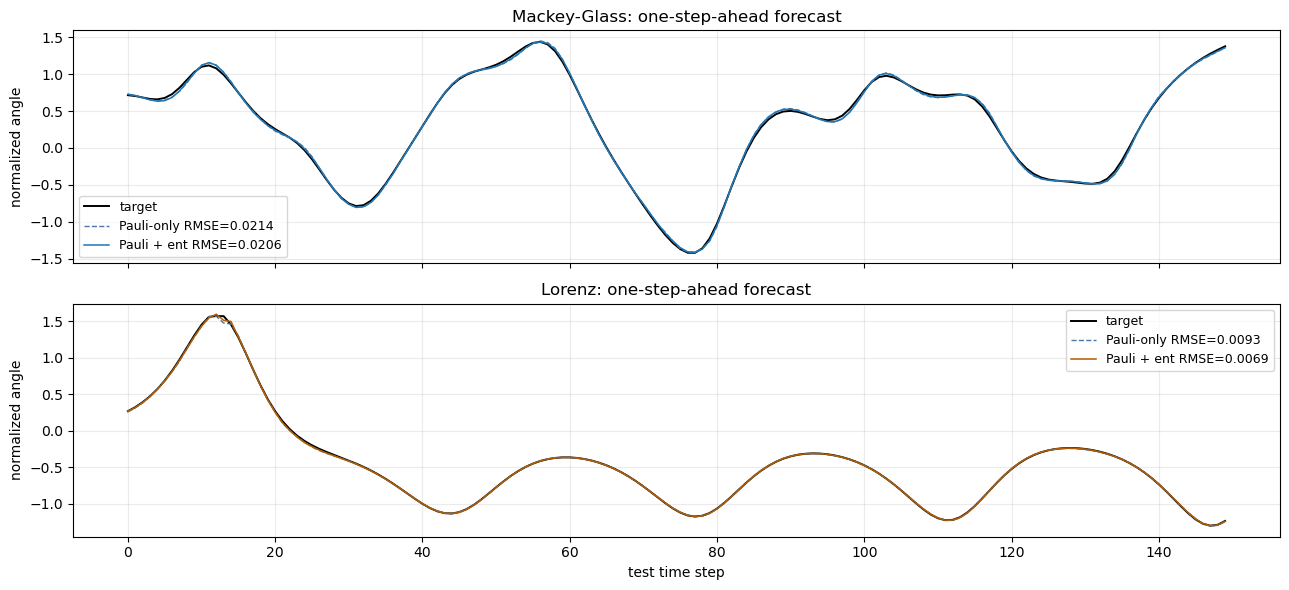

Saved figure: /work/vantn/QuantumEdge_GIC2026/phaseII/notebook/qrc_forecast_comparison.png


In [9]:
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
plot_steps = 150

for ax, dataset, color in zip(axes, ("Mackey-Glass", "Lorenz"), ("#1f77b4", "#b35c00")):
    pauli = experiments[dataset]["Dual reservoir, Pauli-only"]
    ent = experiments[dataset]["Dual reservoir, Pauli + entanglement"]

    ax.plot(ent["y_test"][:plot_steps], color="black", lw=1.4, label="target")
    ax.plot(pauli["y_pred"][:plot_steps], color="#4c78a8", lw=1.0, ls="--",
            label=f"Pauli-only RMSE={pauli['rmse']:.4f}")
    ax.plot(ent["y_pred"][:plot_steps], color=color, lw=1.1,
            label=f"Pauli + ent RMSE={ent['rmse']:.4f}")
    ax.set_title(f"{dataset}: one-step-ahead forecast")
    ax.set_ylabel("normalized angle")
    ax.legend(loc="best", fontsize=9)

axes[-1].set_xlabel("test time step")
plt.tight_layout()
plt.savefig(FIGURE_PATH, dpi=160, bbox_inches="tight")
plt.show()

print(f"Saved figure: {FIGURE_PATH.resolve()}")


## 9. Final Results for the Phase 2 Draft

Run the cell below after all previous cells. It prints the exact values to transfer into Van's placeholders in the Phase 2 draft. If an improvement is negative, do not describe it as a reduction in the paper.


In [10]:
def improvement_sentence(dataset):
    value = paper_metrics[dataset]["entanglement_improvement_pct"]
    if value >= 0:
        return f"reduced RMSE by {value:.1f}% ({dataset})"
    return f"increased RMSE by {-value:.1f}% ({dataset})"

lorenz_imp = paper_metrics["Lorenz"]["entanglement_improvement_pct"]
mg_imp = paper_metrics["Mackey-Glass"]["entanglement_improvement_pct"]

print("=" * 72)
print("PAPER RESULTS - Van placeholders")
print("=" * 72)
print(f"Configuration: n={N_QUBITS}, p_short={SHORT_RESERVOIR.trotter_depth}, "
      f"p_long={LONG_RESERVOIR.trotter_depth}, test targets={N_TEST}")
print()
print("Section 3, % improvement on Lorenz:")
print(f"  {lorenz_imp:.1f}")
print("Section 3, % improvement on Mackey-Glass:")
print(f"  {mg_imp:.1f}")
print()
print("Baseline table, single-reservoir QRC RMSE:")
print(f"  Mackey-Glass: {paper_metrics['Mackey-Glass']['single_rmse']:.6f}")
print(f"  Lorenz:       {paper_metrics['Lorenz']['single_rmse']:.6f}")
print()
print("Suggested sentence:")
if lorenz_imp >= 0 and mg_imp >= 0:
    print(
        "Preliminary experiments on the Lorenz attractor and Mackey-Glass series "
        f"(n = {N_QUBITS} qubits, p = {{{SHORT_RESERVOIR.trotter_depth}, {LONG_RESERVOIR.trotter_depth}}}, "
        f"{N_TEST} test time steps, PennyLane state-vector simulator) show that adding "
        f"entanglement-spectrum features reduced RMSE by {lorenz_imp:.1f}% (Lorenz) "
        f"and {mg_imp:.1f}% (Mackey-Glass) versus Pauli-only readout."
    )
else:
    print(
        "At least one entanglement readout improvement is negative. Report the signed "
        "values from this block and revise the paper sentence so it does not claim a "
        "universal RMSE reduction."
    )
print("=" * 72)


PAPER RESULTS - Van placeholders
Configuration: n=9, p_short=2, p_long=6, test targets=500

Section 3, % improvement on Lorenz:
  25.5
Section 3, % improvement on Mackey-Glass:
  3.6

Baseline table, single-reservoir QRC RMSE:
  Mackey-Glass: 0.023141
  Lorenz:       0.016517

Suggested sentence:
Preliminary experiments on the Lorenz attractor and Mackey-Glass series (n = 9 qubits, p = {2, 6}, 500 test time steps, PennyLane state-vector simulator) show that adding entanglement-spectrum features reduced RMSE by 25.5% (Lorenz) and 3.6% (Mackey-Glass) versus Pauli-only readout.


## 10. Notes for Phase 3 Extension

- Replace the synthetic series with SPX realized variance, VIX, returns, and Garman-Klass volatility features.
- Add classical feedback features if the final architecture keeps the draft's reservoir-state feedback mechanism.
- Run qubit and Trotter-depth sweeps over $n \in \{5,8,10,12,15\}$ and $p \in \{2,4,6\}$.
- Add shot-based and noisy-device studies after the statevector baseline is stable.
